In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

In [3]:
df = pd.read_excel('../data/CBDI3 All Evals for NSS.xlsx', dtype={
    'Adaptive RDI': str,
    'Social-Emotional RDI': str,
    'Communication RDI': str,
    'Motor RDI': str,
    'Cognitive RDI': str,
    'Adaptive-Personal Responsibility RDI': str,
    'Social Emotional-Adult Interaction RDI': str,
    'Social Emotional-Self Concept / Social Role RDI': str,
    'Communication-Receptive Communication RDI': str,
    'Communication-Expressive Communication RDI': str,
    'Motor-Gross Motor RDI': str,
    'Motor-Fine Motor RDI': str,
    'Motor-Perceptual Motor RDI': str,
    'Cognitive-Attention and Memory RDI': str,
    'Cognitive-Reasoning / Academic Skills RDI': str,
    'Cognitive-Perception and Concepts RDI': str})

In [4]:
df.head()

,Child ID,Gender,Date of Birth,Location - Sub Level 1,contract number,Program Label,Adaptive Sum of Scaled Scores,Adaptive Developmental Quotient,Adaptive Percentile Rank,Adaptive 95% Confidence Interval,...,Code 1,Code 2,Code 3,Code 4,Code 5,Code 6,Code 7,Code 8,Code 9,Code 10
0,44879,F,2022-09-27,Southwest,contract 3,BDI-3 Eligibility Evaluation,7.0,85.0,16,77-97,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,47795,F,2020-12-23,Greater Nashville,contract 2,BDI-3 Eligibility Evaluation,16.0,88.0,21,82-96,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,54340,M,2021-06-22,First Tennessee,contract 1,BDI-3 Eligibility Evaluation,8.0,90.0,25,81-101,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,54344,F,2022-03-07,Southeast Tennessee,contract 1,BDI-3 Eligibility Evaluation,13.0,115.0,84,103-123,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,54515,M,2021-11-04,Memphis Delta,contract 3,BDI-3 Eligibility Evaluation,5.0,75.0,5,68-88,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df = df.drop_duplicates()

QUESTION 1

In [6]:
domain_columns = ['Adaptive Developmental Quotient',
    'Social-Emotional Developmental Quotient',
    'Communication Developmental Quotient',
    'Motor Developmental Quotient',
    'Cognitive Developmental Quotient']

In [7]:
domain_scores = df[domain_columns].describe().T.sort_values(by='mean')
print("Domain Performance Summary:\n", domain_scores)

Domain Performance Summary:
                                            count       mean        std   min  \
Communication Developmental Quotient     19469.0  79.604499  20.168400  46.0   
Adaptive Developmental Quotient          19493.0  87.435079  17.438731  46.0   
Cognitive Developmental Quotient         19481.0  89.061804  16.498114  40.0   
Social-Emotional Developmental Quotient  19483.0  94.470051  16.695712  46.0   
Motor Developmental Quotient             19471.0  94.511222  17.288802  42.0   

                                          25%   50%    75%    max  
Communication Developmental Quotient     64.0  79.0   94.0  154.0  
Adaptive Developmental Quotient          76.0  88.0  100.0  148.0  
Cognitive Developmental Quotient         80.0  90.0  100.0  160.0  
Social-Emotional Developmental Quotient  84.0  96.0  106.0  154.0  
Motor Developmental Quotient             85.0  96.0  106.0  154.0  


In [8]:
subdomain_columns = ['Adaptive-Self Care SS',
    'Adaptive-Personal Responsibility SS',
    'Social Emotional-Adult Interaction SS',
    'Social Emotional-Peer Interaction SS',
    'Social Emotional-Self Concept / Social Role SS',
    'Communication-Receptive Communication SS',
    'Communication-Expressive Communication SS',
    'Motor-Gross Motor SS',
    'Motor-Fine Motor SS',
    'Motor-Perceptual Motor SS',
    'Cognitive-Attention and Memory SS',
    'Cognitive-Reasoning / Academic Skills SS',
    'Cognitive-Perception and Concepts SS']

In [9]:
subdomain_scores = df[subdomain_columns].describe().T.sort_values(by='mean')
print("Subdomain Performance Summary:\n", subdomain_scores)

Subdomain Performance Summary:
                                                   count       mean       std  \
Communication-Expressive Communication SS       19472.0   6.493991  3.672590   
Communication-Receptive Communication SS        19485.0   6.709110  3.622658   
Adaptive-Self Care SS                           19494.0   7.453832  3.144153   
Cognitive-Perception and Concepts SS            19482.0   7.785443  3.259881   
Social Emotional-Peer Interaction SS             9694.0   7.834124  3.298726   
Adaptive-Personal Responsibility SS              9698.0   7.957826  3.861019   
Social Emotional-Self Concept / Social Role SS  19486.0   8.032793  3.298105   
Cognitive-Reasoning / Academic Skills SS         9693.0   8.097803  3.203242   
Cognitive-Attention and Memory SS               19484.0   8.407206  2.714675   
Motor-Perceptual Motor SS                        9688.0   8.545417  3.924365   
Motor-Gross Motor SS                            19483.0   8.621568  3.042683   
Motor-Fi

QUESTION 2

In [10]:
df['child_score_variance'] = df[domain_columns].std(axis=1)

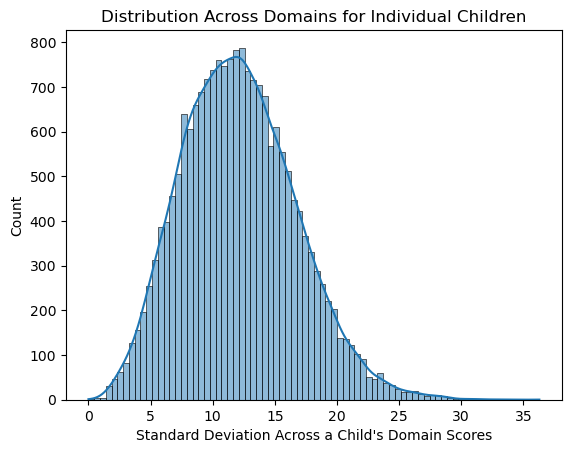

In [11]:
sns.histplot(df['child_score_variance'], kde=True)
plt.title("Distribution Across Domains for Individual Children")
plt.xlabel("Standard Deviation Across a Child's Domain Scores")
plt.show()

QUESTION 3

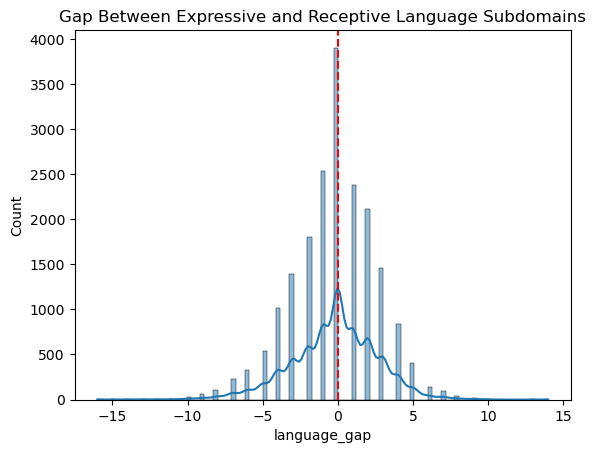

Mean language gap across population: -0.21305665416816477


In [12]:
df['language_gap'] = df['Communication-Expressive Communication SS'] - df['Communication-Receptive Communication SS']

sns.histplot(df['language_gap'], kde=True)
plt.axvline(0, color='red', linestyle='--')
plt.title("Gap Between Expressive and Receptive Language Subdomains")
plt.show()

print("Mean language gap across population:", df['language_gap'].mean())

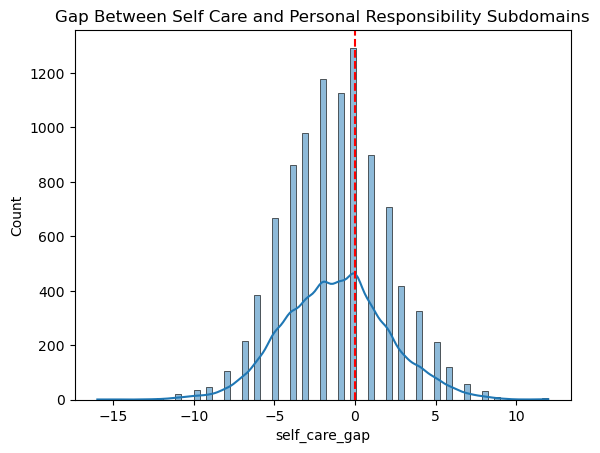

Mean gap across population: -1.18758378880066


In [13]:
df['self_care_gap'] = df['Adaptive-Self Care SS'] - df['Adaptive-Personal Responsibility SS']

sns.histplot(df['self_care_gap'], kde=True)
plt.axvline(0, color='red', linestyle='--')
plt.title("Gap Between Self Care and Personal Responsibility Subdomains")
plt.show()

print("Mean gap across population:", df['self_care_gap'].mean())

QUESTION 4

In [14]:
df['Date of Birth'] = pd.to_datetime(df['Date of Birth'])

In [15]:
df['Age'] = ((pd.Timestamp('now') - df['Date of Birth']) / np.timedelta64(1, 'D') / 365.25).astype(int)

In [16]:
df.columns.tolist()

['Child ID',
 'Gender',
 'Date of Birth',
 'Location - Sub Level 1',
 'contract number',
 'Program Label',
 'Adaptive Sum of Scaled Scores',
 'Adaptive Developmental Quotient',
 'Adaptive Percentile Rank',
 'Adaptive 95% Confidence Interval',
 'Adaptive RDI',
 'Adaptive Z-Score',
 'Adaptive T-Score',
 'Adaptive NCE',
 'Social-Emotional Sum of Scaled Scores',
 'Social-Emotional Developmental Quotient',
 'Social-Emotional Percentile Rank',
 'Social-Emotional 95% Confidence Interval',
 'Social-Emotional RDI',
 'Social-Emotional Z-Score',
 'Social-Emotional T-Score',
 'Social-Emotional NCE',
 'Communication Sum of Scaled Scores',
 'Communication Developmental Quotient',
 'Communication Percentile Rank',
 'Communication 95% Confidence Interval',
 'Communication RDI',
 'Communication Z-Score',
 'Communication T-Score',
 'Communication NCE',
 'Motor Sum of Scaled Scores',
 'Motor Developmental Quotient',
 'Motor Percentile Rank',
 'Motor 95% Confidence Interval',
 'Motor RDI',
 'Motor Z-Score

Correlation between Age and Domain Scores:
 Age                                        1.000000
Adaptive Developmental Quotient           -0.193744
Social-Emotional Developmental Quotient   -0.191257
Communication Developmental Quotient      -0.376025
Motor Developmental Quotient              -0.095459
Cognitive Developmental Quotient          -0.269207
Name: Age, dtype: float64


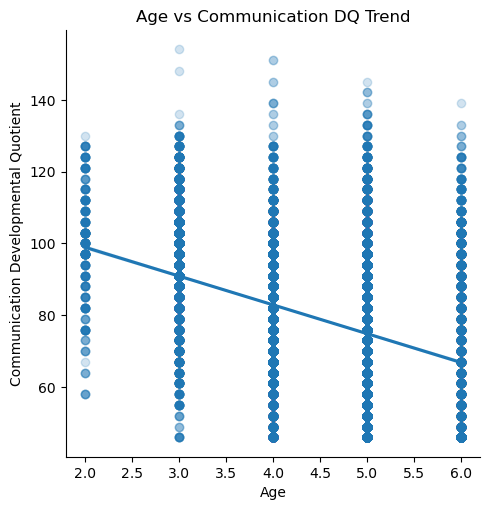

In [20]:
age_domain_correlation = df[['Age'] + domain_columns].corr()
print("Correlation between Age and Domain Scores:\n", age_domain_correlation['Age'])
sns.lmplot(data=df, x='Age', y='Communication Developmental Quotient', scatter_kws={'alpha':0.2})
plt.title("Age vs Communication DQ Trend")
plt.show()

QUESTION 5

QUESTION 6

In [22]:
print(df.groupby('Program Label')[domain_columns].mean())

                                    Adaptive Developmental Quotient  \
Program Label                                                         
BDI-3 Annual Evaluation                                   84.352984   
BDI-3 Eligibility Evaluation                              89.183029   
BDI-3 Milestone or Exit Evaluation                        85.605911   

                                    Social-Emotional Developmental Quotient  \
Program Label                                                                 
BDI-3 Annual Evaluation                                           92.786978   
BDI-3 Eligibility Evaluation                                      95.430313   
BDI-3 Milestone or Exit Evaluation                                93.064039   

                                    Communication Developmental Quotient  \
Program Label                                                              
BDI-3 Annual Evaluation                                        76.915011   
BDI-3 Eligibility Ev